# Transfer Learning in Deep Reinforcement Learning


## Implementación Completa: DQN Baseline, Policy Distillation y Reward Shaping

**Curso:** ISIS4222 — Reinforcement Learning  
**Universidad de los Andes — 2026-I**  


---

### Contenido del Notebook

1. [**Baseline DQN**](#2.-Experimento-1:-DQN-Baseline-(Sin-Transfer-Learning)) en CartPole-v1 (sin Transfer Learning)
2. [**Policy Distillation**](#4.-Experimento-2:-Policy-Distillation) — Teacher DQN → Student mediante KL-Divergence
3. [**Reward Shaping (PBRS)**](#5.-Experimento-3:-Potential-Based-Reward-Shaping-(PBRS)) — Función potencial derivada del teacher
4. [**Comparación y Análisis**](#6.-Comparación-y-Análisis) — Curvas de aprendizaje, métricas TL

### Referencias Clave
- Zhu, Lin & Zhou (2021/2023). *Transfer Learning in Deep RL: A Survey*. IEEE TPAMI.
- Ng, Harada & Russell (1999). *Policy invariance under reward transformations*. ICML.
- Rusu et al. (2015). *Policy Distillation*. arXiv.
- Hinton et al. (2014). *Distilling the Knowledge in a Neural Network*. NIPS Workshop.


## 0. Configuración e Imports

In [ ]:
# importar e ignorar warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
print(f"Gymnasium version: {gym.__version__}")
print(f"PyTorch version: {torch.__version__}")


Usando dispositivo: cuda
Gymnasium version: 1.3.0
PyTorch version: 2.10.0+cu128


In [ ]:
# Definición de semilla global
SEED = 71

random.seed(SEED) # Python
np.random.seed(SEED) # Numpy

torch.manual_seed(SEED) # PyTorch
torch.cuda.manual_seed(SEED) # PyTorch para GPU
torch.cuda.manual_seed_all(SEED) # PyTorch para múltiples GPU

## 1. Componentes Base: Red Q, Replay Buffer, Agente DQN

### Arquitectura de la Red Q

La red neuronal aproxima la función Q: $Q(s, a; \\theta)$ donde $\\theta$ son los parámetros.
Para CartPole con estado de dimensión 4 y 2 acciones, usamos una red feedforward con dos capas ocultas.


### Replay Buffer

Almacena transiciones $(s, a, r, s', done)$ para entrenamiento off-policy con sampling uniforme.


In [ ]:
# ========================================
# Red Q-Network
# ========================================
class QNetwork(nn.Module):
    """Red neuronal para aproximar Q(s,a).
    Arquitectura: 2 capas ocultas con ReLU.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# ========================================
# Experience Replay Buffer
# ========================================
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    """Buffer circular para almacenar y muestrear transiciones."""
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        states = torch.FloatTensor(np.array(batch.state)).to(device)
        actions = torch.LongTensor(batch.action).to(device)
        rewards = torch.FloatTensor(batch.reward).to(device)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(device)
        dones = torch.FloatTensor(batch.done).to(device)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print("✓ QNetwork y ReplayBuffer definidos correctamente.")
print(f"  QNetwork params: {sum(p.numel() for p in QNetwork(4,2).parameters()):,}")


✓ QNetwork y ReplayBuffer definidos correctamente.
  QNetwork params: 17,410


### Agente DQN

Implementación completa de DQN con:
- **ε-greedy** exploration con decaimiento exponencial
- **Target network** con actualización periódica (hard update)
- **Experience replay** con muestreo uniforme
- **Huber loss** (smooth L1) para estabilidad


In [ ]:
class DQNAgent:
    """Agente DQN completo con target network y epsilon-greedy."""

    def __init__(self, state_dim, action_dim, hidden_dim=128, lr=1e-3,
                 gamma=0.99, epsilon_start=1.0, epsilon_end=0.01,
                 epsilon_decay=0.995, buffer_size=50000, batch_size=64,
                 target_update_freq=10):

        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        # Redes
        self.q_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        self.steps = 0

    def select_action(self, state, eval_mode=False):
        """Selección ε-greedy de acción."""
        if not eval_mode and random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_t)
            return q_values.argmax(dim=1).item()

    def get_q_values(self, state):
        """Obtener Q-values para un estado (usado en distillation)."""
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_network(state_t).squeeze(0)

    def get_value(self, state):
        """V(s) = max_a Q(s,a) — usado para reward shaping."""
        q = self.get_q_values(state)
        return q.max().item()

    def update(self):
        """Un paso de optimización con experiencias del buffer."""
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Q(s, a) actual
        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Q target: r + γ * max_a' Q_target(s', a')
        with torch.no_grad():
            next_q = self.target_network(next_states).max(dim=1)[0]
            target = rewards + self.gamma * next_q * (1 - dones)

        # Huber loss
        loss = F.smooth_l1_loss(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def update_target(self):
        self.target_network.load_state_dict(self.q_network.state_dict())


✓ DQNAgent definido correctamente.


In [ ]:
def train_agent(agent, env_name='CartPole-v1', num_episodes=300,
                reward_shaping_fn=None, eval_every=10, verbose=True):
    """Entrenar un agente DQN, opcionalmente con reward shaping.

    Args:
        agent: DQNAgent
        env_name: nombre del entorno Gymnasium
        reward_shaping_fn: función f(s, s') -> shaping_reward (opcional)
        eval_every: cada cuántos episodios evaluar
        verbose: imprimir progreso

    Returns:
        episode_rewards: lista de recompensas por episodio
        eval_rewards: lista de (episodio, reward_promedio) en evaluación
    """
    env = gym.make(env_name)
    episode_rewards = []
    eval_rewards = []

    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Aplicar reward shaping si se proporciona
            shaped_reward = reward
            if reward_shaping_fn is not None:
                shaped_reward = reward + reward_shaping_fn(state, next_state, done)

            agent.buffer.push(state, action, shaped_reward, next_state, float(done))
            agent.update()

            state = next_state
            total_reward += reward  # Tracking con reward original

        agent.decay_epsilon()
        if ep % agent.target_update_freq == 0:
            agent.update_target()

        episode_rewards.append(total_reward)

        # Evaluación periódica
        if ep % eval_every == 0:
            eval_r = evaluate_agent(agent, env_name, num_eval=5)
            eval_rewards.append((ep, eval_r))
            if verbose and ep % 50 == 0:
                print(f"  Ep {ep:4d} | Train: {total_reward:6.1f} | "
                      f"Eval: {eval_r:6.1f} | ε: {agent.epsilon:.3f}")

    env.close()
    return episode_rewards, eval_rewards


def evaluate_agent(agent, env_name='CartPole-v1', num_eval=10):
    """Evaluar agente sin exploración."""
    env = gym.make(env_name)
    rewards = []
    for i in range(num_eval):
        state, _ = env.reset(seed=1000 + i)
        total = 0
        done = False
        while not done:
            action = agent.select_action(state, eval_mode=True)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
        rewards.append(total)
    env.close()
    return np.mean(rewards)



✓ Funciones de entrenamiento y evaluación definidas.


## 2. Experimento 1: DQN Baseline (Sin Transfer Learning)

Entrenamos un agente DQN desde cero en CartPole-v1.
Este será nuestro **baseline** para comparar contra los métodos de Transfer Learning.

**CartPole-v1:**
- Estado: 4D (posición carro, velocidad, ángulo poste, velocidad angular)
- Acciones: 2 (izquierda, derecha)
- Recompensa: +1 por cada paso que el poste se mantiene vertical
- Umbral de éxito: 475 (promedio sobre 100 episodios)


In [ ]:
print("=" * 60)
print("EXPERIMENTO 1: DQN BASELINE (sin Transfer Learning)")
print("=" * 60)

# Crear y entrenar agente baseline
baseline_agent = DQNAgent(
    state_dim=4, action_dim=2, hidden_dim=128,
    lr=1e-3, gamma=0.99, epsilon_start=1.0,
    epsilon_end=0.01, epsilon_decay=0.995,
    batch_size=64, target_update_freq=10
)

baseline_rewards, baseline_evals = train_agent(
    baseline_agent, num_episodes=300, verbose=True
)

final_eval = evaluate_agent(baseline_agent, num_eval=20)
print(f"\nRendimiento final baseline: {final_eval:.1f}")


EXPERIMENTO 1: DQN BASELINE (sin Transfer Learning)
  Ep    0 | Train:    8.0 | Eval:    9.6 | ε: 0.995
  Ep   50 | Train:   17.0 | Eval:  170.4 | ε: 0.774
  Ep  100 | Train:   65.0 | Eval:  114.4 | ε: 0.603
  Ep  150 | Train:  119.0 | Eval:   52.2 | ε: 0.469
  Ep  200 | Train:   13.0 | Eval:  145.6 | ε: 0.365
  Ep  250 | Train:   97.0 | Eval:  149.4 | ε: 0.284

Rendimiento final baseline: 500.0


## 3. Entrenamiento del Teacher (Expert DQN)

Antes de aplicar Transfer Learning, necesitamos un **teacher bien entrenado**.
Entrenamos un DQN por más episodios para que converja a una política cercana al óptimo.

Este teacher proporcionará:
1. **Q-values** para Policy Distillation (distribución de acciones)
2. **V(s) = max_a Q(s,a)** como función potencial para Reward Shaping


In [ ]:
print("=" * 60)
print("ENTRENANDO TEACHER (DQN Expert)")
print("=" * 60)

teacher_agent = DQNAgent(
    state_dim=4, action_dim=2, hidden_dim=128,
    lr=1e-3, gamma=0.99, epsilon_start=1.0,
    epsilon_end=0.01, epsilon_decay=0.993,
    batch_size=64, target_update_freq=10
)

teacher_rewards, teacher_evals = train_agent(
    teacher_agent, num_episodes=500, verbose=True
)

teacher_eval = evaluate_agent(teacher_agent, num_eval=30)
print(f"\n✓ Teacher entrenado. Rendimiento: {teacher_eval:.1f}")
print(f"  (Se usará como fuente de conocimiento para TL)")


ENTRENANDO TEACHER (DQN Expert)
  Ep    0 | Train:   13.0 | Eval:    9.0 | ε: 0.993
  Ep   50 | Train:   17.0 | Eval:  184.0 | ε: 0.699
  Ep  100 | Train:   50.0 | Eval:  219.6 | ε: 0.492
  Ep  150 | Train:   14.0 | Eval:  125.8 | ε: 0.346
  Ep  200 | Train:  210.0 | Eval:  118.4 | ε: 0.244
  Ep  250 | Train:  294.0 | Eval:  155.2 | ε: 0.171
  Ep  300 | Train:  110.0 | Eval:  114.6 | ε: 0.121
  Ep  350 | Train:  119.0 | Eval:  100.2 | ε: 0.085
  Ep  400 | Train:  105.0 | Eval:   99.0 | ε: 0.060
  Ep  450 | Train:   94.0 | Eval:   42.8 | ε: 0.042

✓ Teacher entrenado. Rendimiento: 153.8
  (Se usará como fuente de conocimiento para TL)


## 4. Experimento 2: Policy Distillation

### Teoría (Rusu et al., 2015; Hinton et al., 2014)

**Policy Distillation** transfiere conocimiento minimizando la divergencia entre las distribuciones de acción del teacher y el student:

$$\\min_\\theta D_{KL}(\\pi^{teacher}(\\cdot|s) \\| \\pi^{student}_\\theta(\\cdot|s))$$

Donde las distribuciones se obtienen aplicando softmax con temperatura $\\tau$ sobre los Q-values:

$$\\pi(a|s) = \\frac{e^{Q(s,a)/\\tau}}{\\sum_{a'} e^{Q(s,a')/\\tau}}$$

**Temperatura τ:**
- τ alta → distribución más suave (más información sobre Q relativos)
- τ baja → distribución más peaked (más parecido a argmax)



### Implementación

El student se entrena de forma **híbrida**:
1. **Loss RL**: Bellman loss estándar (DQN)
2. **Loss Distillation**: KL-divergence con teacher
3. **Loss total**: `L = L_RL + α * L_distill`

In [ ]:
class DistillationDQNAgent(DQNAgent):
    """DQN con loss de destilación del teacher.

    Combina:
    - Loss RL: Bellman error estándar
    - Loss Distillation: KL(teacher || student) sobre softmax(Q/τ)
    """

    def __init__(self, teacher, distill_alpha=0.5, temperature=3.0, **kwargs):
        super().__init__(**kwargs)
        self.teacher = teacher
        self.distill_alpha = distill_alpha
        self.temperature = temperature

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # === Loss RL (DQN estándar) ===
        q_values = self.q_network(states)
        q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(dim=1)[0]
            target = rewards + self.gamma * next_q * (1 - dones)

        loss_rl = F.smooth_l1_loss(q_selected, target)

        # === Loss Distillation (KL-Divergence) ===
        with torch.no_grad():
            teacher_q = self.teacher.q_network(states)
            teacher_probs = F.softmax(teacher_q / self.temperature, dim=1)

        student_log_probs = F.log_softmax(q_values / self.temperature, dim=1)
        loss_distill = F.kl_div(student_log_probs, teacher_probs,
                                reduction='batchmean') * (self.temperature ** 2)

        # === Loss combinado ===
        loss = (1 - self.distill_alpha) * loss_rl + self.distill_alpha * loss_distill

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        return loss.item()



✓ DistillationDQNAgent definido.
  Combina Bellman loss + KL-divergence con teacher Q-values.


In [ ]:
print("=" * 60)
print("EXPERIMENTO 2: POLICY DISTILLATION")
print("=" * 60)

distill_agent = DistillationDQNAgent(
    teacher=teacher_agent,
    distill_alpha=0.5,       # Balance RL vs distillation
    temperature=3.0,          # Softmax temperature
    state_dim=4, action_dim=2, hidden_dim=128,
    lr=1e-3, gamma=0.99, epsilon_start=0.5,  # ε más bajo: teacher guía
    epsilon_end=0.01, epsilon_decay=0.995,
    batch_size=64, target_update_freq=10
)

distill_rewards, distill_evals = train_agent(
    distill_agent, num_episodes=300, verbose=True
)

distill_eval = evaluate_agent(distill_agent, num_eval=20)
print(f"\nRendimiento final Policy Distillation: {distill_eval:.1f}")


EXPERIMENTO 2: POLICY DISTILLATION
  Ep    0 | Train:   19.0 | Eval:    9.6 | ε: 0.497
  Ep   50 | Train:   18.0 | Eval:  500.0 | ε: 0.387
  Ep  100 | Train:   49.0 | Eval:  420.4 | ε: 0.301
  Ep  150 | Train:   11.0 | Eval:  147.4 | ε: 0.235
  Ep  200 | Train:  100.0 | Eval:  119.0 | ε: 0.183
  Ep  250 | Train:  100.0 | Eval:   91.4 | ε: 0.142

Rendimiento final Policy Distillation: 106.0


## 5. Experimento 3: Potential-Based Reward Shaping (PBRS)

### Teoría (Ng, Harada & Russell, 1999)

**Reward Shaping** reconstruye la función de recompensa con conocimiento externo:

$$R'(s, a, s') = R(s, a, s') + F(s, a, s')$$

Para **PBRS**, la función de shaping es la diferencia de potenciales:

$$F(s, a, s') = \\gamma \\Phi(s') - \\Phi(s)$$

Donde $\\Phi(s)$ es una función potencial que evalúa la calidad de un estado.

**Propiedad clave:** PBRS preserva la invarianza de la política óptima:
$$Q^*_{M'}(s, a) = Q^*_M(s, a) - \\Phi(s)$$



### Implementación

Usamos $\\Phi(s) = V^{teacher}(s) = \\max_a Q^{teacher}(s, a)$ como función potencial.

Esto transfiere el conocimiento del teacher sin alterar la política óptima del entorno.

In [ ]:
def create_pbrs_shaping_fn(teacher_agent, gamma=0.99, scale=0.1):
    """Crear función de reward shaping basada en potenciales (PBRS).

    F(s, a, s') = γ * Φ(s') - Φ(s)

    donde Φ(s) = V_teacher(s) = max_a Q_teacher(s, a)

    Propiedad: preserva la política óptima del MDP original.

    Args:
        teacher_agent: agente DQN teacher entrenado
        gamma: factor de descuento
        scale: factor de escala para controlar la magnitud del shaping
    """
    def shaping_fn(state, next_state, done):
        phi_s = teacher_agent.get_value(state)
        if done:
            phi_s_next = 0.0  # Estado terminal
        else:
            phi_s_next = teacher_agent.get_value(next_state)

        # F(s, a, s') = γ * Φ(s') - Φ(s)
        shaping_reward = scale * (gamma * phi_s_next - phi_s)
        return shaping_reward

    return shaping_fn

# Verificar la función de shaping
env_test = gym.make('CartPole-v1')
s_test, _ = env_test.reset(seed=0)
s_next, _, _, _, _ = env_test.step(0)
env_test.close()

pbrs_fn = create_pbrs_shaping_fn(teacher_agent, gamma=0.99, scale=0.1)
sample_shaping = pbrs_fn(s_test, s_next, False)
print(f"✓ PBRS shaping function creada.")
print(f"  Ejemplo: Φ(s) = {teacher_agent.get_value(s_test):.3f}")
print(f"  Ejemplo: Φ(s') = {teacher_agent.get_value(s_next):.3f}")
print(f"  Shaping reward: {sample_shaping:.4f}")


✓ PBRS shaping function creada.
  Ejemplo: Φ(s) = 41.923
  Ejemplo: Φ(s') = 42.037
  Shaping reward: -0.0306


In [ ]:
print("=" * 60)
print("EXPERIMENTO 3: REWARD SHAPING (PBRS)")
print("=" * 60)

# Crear función de shaping con el teacher
pbrs_fn = create_pbrs_shaping_fn(teacher_agent, gamma=0.99, scale=0.1)

# Crear agente nuevo (desde cero) pero con reward shaping
shaped_agent = DQNAgent(
    state_dim=4, action_dim=2, hidden_dim=128,
    lr=1e-3, gamma=0.99, epsilon_start=1.0,
    epsilon_end=0.01, epsilon_decay=0.995,
    batch_size=64, target_update_freq=10
)

shaped_rewards, shaped_evals = train_agent(
    shaped_agent, num_episodes=300,
    reward_shaping_fn=pbrs_fn, verbose=True
)

shaped_eval = evaluate_agent(shaped_agent, num_eval=20)
print(f"\nRendimiento final Reward Shaping: {shaped_eval:.1f}")


EXPERIMENTO 3: REWARD SHAPING (PBRS)
  Ep    0 | Train:   34.0 | Eval:    9.6 | ε: 0.995
  Ep   50 | Train:   25.0 | Eval:  169.2 | ε: 0.774
  Ep  100 | Train:   14.0 | Eval:  185.6 | ε: 0.603
  Ep  150 | Train:   12.0 | Eval:  108.0 | ε: 0.469
  Ep  200 | Train:  126.0 | Eval:  206.0 | ε: 0.365
  Ep  250 | Train:   46.0 | Eval:  429.4 | ε: 0.284

Rendimiento final Reward Shaping: 500.0


## 6. Comparación y Análisis

### Métricas de Evaluación (del survey)

| Métrica | Abreviatura | Descripción |
|---------|------------|-------------|
| Jumpstart Performance | jp | Rendimiento inicial del agente |
| Asymptotic Performance | ap | Rendimiento final del agente |
| Time to Threshold | tt | Episodios para alcanzar umbral |
| Accumulated Rewards | ar | Área bajo la curva de aprendizaje |


In [ ]:
def smooth(data, window=20):
    """Moving average para suavizar curvas."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

def compute_tl_metrics(rewards, threshold=200, window=20):
    """Calcular métricas de TL."""
    smoothed = smooth(rewards, window)
    metrics = {}

    # Jumpstart: promedio de los primeros 20 episodios
    metrics['jumpstart'] = np.mean(rewards[:20])

    # Asymptotic: promedio de los últimos 30 episodios
    metrics['asymptotic'] = np.mean(rewards[-30:])

    # Time to threshold
    tt = None
    for i in range(len(smoothed)):
        if smoothed[i] >= threshold:
            tt = i + window  # ajustar por ventana
            break
    metrics['time_to_threshold'] = tt if tt else len(rewards)

    # Accumulated rewards (AUC)
    metrics['accumulated'] = np.sum(rewards)

    return metrics

# Calcular métricas
m_baseline = compute_tl_metrics(baseline_rewards)
m_distill = compute_tl_metrics(distill_rewards)
m_shaped = compute_tl_metrics(shaped_rewards)

print("=" * 70)
print(f"{'Métrica':<25} {'Baseline':>12} {'Distillation':>12} {'PBRS':>12}")
print("=" * 70)
for key in ['jumpstart', 'asymptotic', 'time_to_threshold', 'accumulated']:
    label = {
        'jumpstart': 'Jumpstart (jp)',
        'asymptotic': 'Asymptotic (ap)',
        'time_to_threshold': 'Time to Threshold (tt)',
        'accumulated': 'Accumulated (ar)'
    }[key]
    print(f"{label:<25} {m_baseline[key]:>12.1f} {m_distill[key]:>12.1f} {m_shaped[key]:>12.1f}")
print("=" * 70)

# Transfer ratios
tr_distill = m_distill['asymptotic'] / max(m_baseline['asymptotic'], 1)
tr_shaped = m_shaped['asymptotic'] / max(m_baseline['asymptotic'], 1)
print(f"\nTransfer Ratio (tr):")
print(f"  Distillation: {tr_distill:.3f}")
print(f"  PBRS:         {tr_shaped:.3f}")


Métrica                       Baseline Distillation         PBRS
Jumpstart (jp)                    18.8         60.0         21.9
Asymptotic (ap)                  122.8         60.5        140.4
Time to Threshold (tt)           300.0        300.0        300.0
Accumulated (ar)               16878.0      19025.0      17384.0

Transfer Ratio (tr):
  Distillation: 0.493
  PBRS:         1.144


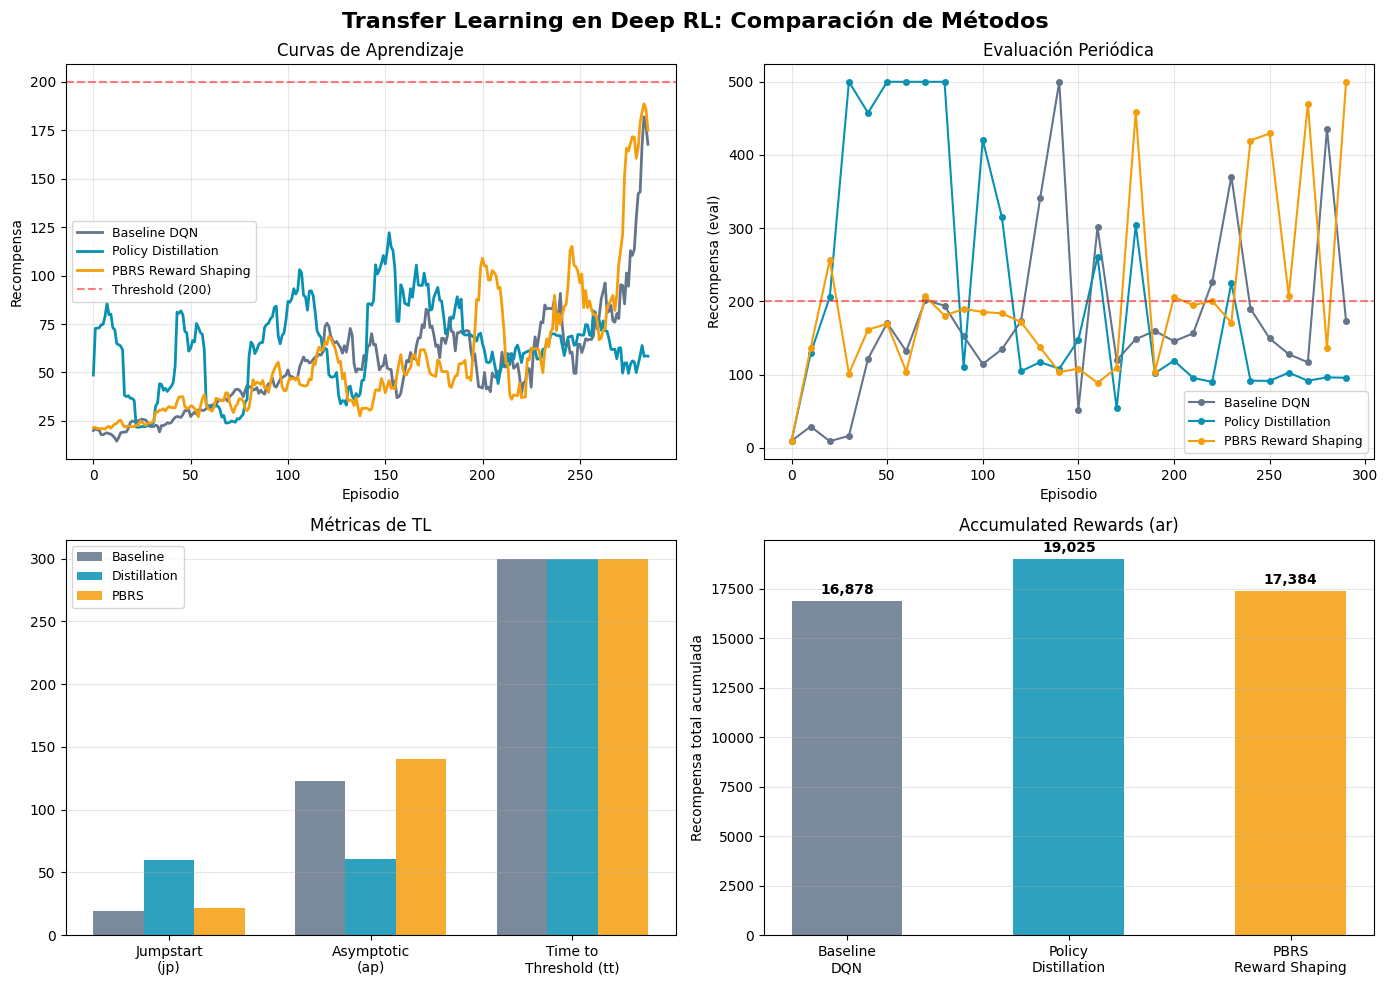


✓ Gráfica guardada en tl_comparison.png


In [ ]:
# ========================================
# Visualización Comparativa
# ========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transfer Learning en Deep RL: Comparación de Métodos',
             fontsize=16, fontweight='bold', y=0.98)

colors = {'Baseline DQN': '#64748B', 'Policy Distillation': '#0891B2', 'PBRS Reward Shaping': '#F59E0B'}

# --- Plot 1: Curvas de aprendizaje (suavizadas) ---
ax1 = axes[0, 0]
for label, rewards, color in [
    ('Baseline DQN', baseline_rewards, colors['Baseline DQN']),
    ('Policy Distillation', distill_rewards, colors['Policy Distillation']),
    ('PBRS Reward Shaping', shaped_rewards, colors['PBRS Reward Shaping'])
]:
    smoothed = smooth(rewards, 15)
    ax1.plot(smoothed, label=label, color=color, linewidth=2)
ax1.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Threshold (200)')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa')
ax1.set_title('Curvas de Aprendizaje')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Evaluación periódica ---
ax2 = axes[0, 1]
for label, evals, color in [
    ('Baseline DQN', baseline_evals, colors['Baseline DQN']),
    ('Policy Distillation', distill_evals, colors['Policy Distillation']),
    ('PBRS Reward Shaping', shaped_evals, colors['PBRS Reward Shaping'])
]:
    eps, rew = zip(*evals)
    ax2.plot(eps, rew, 'o-', label=label, color=color, markersize=4, linewidth=1.5)
ax2.axhline(y=200, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Recompensa (eval)')
ax2.set_title('Evaluación Periódica')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Barras de métricas ---
ax3 = axes[1, 0]
metrics_names = ['Jumpstart\n(jp)', 'Asymptotic\n(ap)', 'Time to\nThreshold (tt)']
baseline_vals = [m_baseline['jumpstart'], m_baseline['asymptotic'], m_baseline['time_to_threshold']]
distill_vals = [m_distill['jumpstart'], m_distill['asymptotic'], m_distill['time_to_threshold']]
shaped_vals = [m_shaped['jumpstart'], m_shaped['asymptotic'], m_shaped['time_to_threshold']]

x = np.arange(len(metrics_names))
width = 0.25
ax3.bar(x - width, baseline_vals, width, label='Baseline', color=colors['Baseline DQN'], alpha=0.85)
ax3.bar(x, distill_vals, width, label='Distillation', color=colors['Policy Distillation'], alpha=0.85)
ax3.bar(x + width, shaped_vals, width, label='PBRS', color=colors['PBRS Reward Shaping'], alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names)
ax3.set_title('Métricas de TL')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Accumulated rewards (AUC) ---
ax4 = axes[1, 1]
auc_vals = [m_baseline['accumulated'], m_distill['accumulated'], m_shaped['accumulated']]
auc_labels = ['Baseline\nDQN', 'Policy\nDistillation', 'PBRS\nReward Shaping']
auc_colors = [colors['Baseline DQN'], colors['Policy Distillation'], colors['PBRS Reward Shaping']]
bars = ax4.bar(auc_labels, auc_vals, color=auc_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, auc_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.set_title('Accumulated Rewards (ar)')
ax4.set_ylabel('Recompensa total acumulada')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Gráfica guardada en tl_comparison.png")


## 7. Visualización: Distribuciones Teacher vs Student

Visualizamos cómo la distribución de acciones del student converge hacia la del teacher
tras el proceso de destilación. Esto ilustra la transferencia de conocimiento a nivel de política.


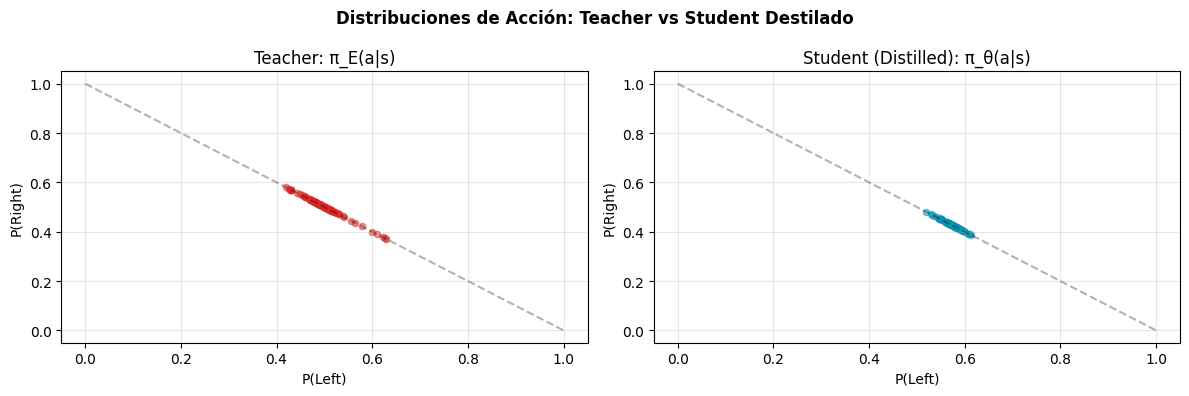

KL-Divergence promedio (Teacher || Student): 0.0144


In [ ]:
# Comparar distribuciones teacher vs student en estados de muestra
env_vis = gym.make('CartPole-v1')
sample_states = []
state, _ = env_vis.reset(seed=42)
for _ in range(100):
    sample_states.append(state)
    action = teacher_agent.select_action(state, eval_mode=True)
    state, _, terminated, truncated, _ = env_vis.step(action)
    if terminated or truncated:
        state, _ = env_vis.reset()
env_vis.close()

# Obtener distribuciones
tau = 1.0  # temperatura para visualización
teacher_probs_list = []
student_probs_list = []

for s in sample_states:
    s_t = torch.FloatTensor(s).unsqueeze(0).to(device)
    with torch.no_grad():
        t_q = teacher_agent.q_network(s_t)
        s_q = distill_agent.q_network(s_t)
        teacher_probs_list.append(F.softmax(t_q / tau, dim=1).cpu().numpy()[0])
        student_probs_list.append(F.softmax(s_q / tau, dim=1).cpu().numpy()[0])

teacher_probs = np.array(teacher_probs_list)
student_probs = np.array(student_probs_list)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Teacher distribution
ax1 = axes[0]
ax1.scatter(teacher_probs[:, 0], teacher_probs[:, 1], alpha=0.5, c='#DC2626', s=20)
ax1.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax1.set_xlabel('P(Left)')
ax1.set_ylabel('P(Right)')
ax1.set_title('Teacher: π_E(a|s)')
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, alpha=0.3)

# Student distribution
ax2 = axes[1]
ax2.scatter(student_probs[:, 0], student_probs[:, 1], alpha=0.5, c='#0891B2', s=20)
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax2.set_xlabel('P(Left)')
ax2.set_ylabel('P(Right)')
ax2.set_title('Student (Distilled): π_θ(a|s)')
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, alpha=0.3)

plt.suptitle('Distribuciones de Acción: Teacher vs Student Destilado', fontweight='bold')
plt.tight_layout()
plt.show()

# KL divergence promedio
kl_divs = []
for t_p, s_p in zip(teacher_probs, student_probs):
    kl = np.sum(t_p * np.log(t_p / (s_p + 1e-8) + 1e-8))
    kl_divs.append(kl)
print(f"KL-Divergence promedio (Teacher || Student): {np.mean(kl_divs):.4f}")


## 8. Análisis del Reward Shaping

Visualizamos la función potencial Φ(s) del teacher y cómo modifica las recompensas.
Verificamos la propiedad de invarianza: PBRS no debe cambiar la política óptima.


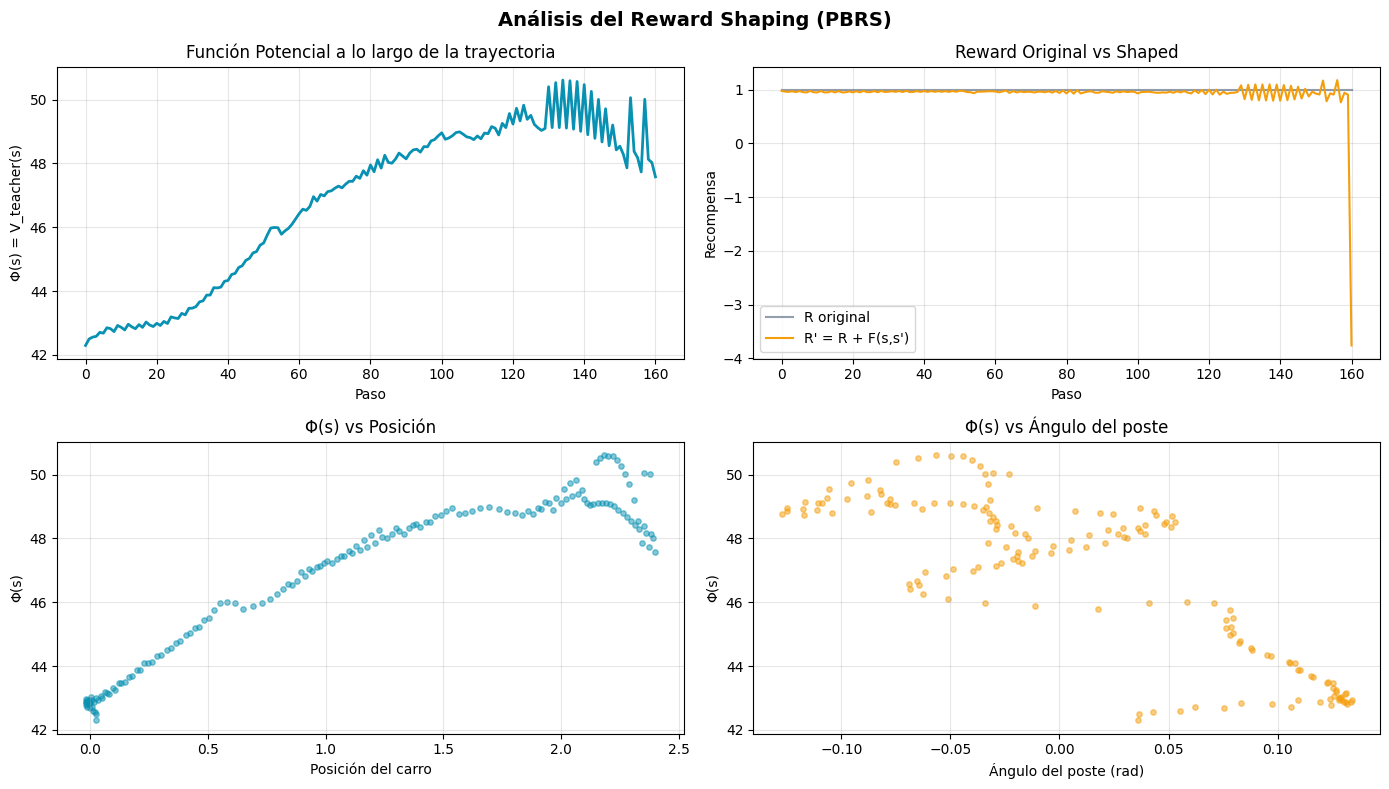

Duración de la trayectoria: 161 pasos
Φ promedio: 46.83, min: 42.30, max: 50.61


In [ ]:
# Visualizar Φ(s) a lo largo de una trayectoria
env_traj = gym.make('CartPole-v1')
state, _ = env_traj.reset(seed=42)

potentials = []
original_rewards = []
shaped_rewards_list = []
positions = []
angles = []

done = False
while not done:
    phi_s = teacher_agent.get_value(state)
    potentials.append(phi_s)
    positions.append(state[0])
    angles.append(state[2])

    action = teacher_agent.select_action(state, eval_mode=True)
    next_state, reward, terminated, truncated, _ = env_traj.step(action)
    done = terminated or truncated

    original_rewards.append(reward)
    shaping = pbrs_fn(state, next_state, done)
    shaped_rewards_list.append(reward + shaping)
    state = next_state

env_traj.close()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Análisis del Reward Shaping (PBRS)', fontsize=14, fontweight='bold')

# Función potencial
ax1 = axes[0, 0]
ax1.plot(potentials, color='#0891B2', linewidth=2)
ax1.set_xlabel('Paso')
ax1.set_ylabel('Φ(s) = V_teacher(s)')
ax1.set_title('Función Potencial a lo largo de la trayectoria')
ax1.grid(True, alpha=0.3)

# Rewards original vs shaped
ax2 = axes[0, 1]
ax2.plot(original_rewards, label='R original', color='#64748B', linewidth=1.5, alpha=0.7)
ax2.plot(shaped_rewards_list, label="R' = R + F(s,s')", color='#F59E0B', linewidth=1.5)
ax2.set_xlabel('Paso')
ax2.set_ylabel('Recompensa')
ax2.set_title('Reward Original vs Shaped')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Φ vs posición del carro
ax3 = axes[1, 0]
ax3.scatter(positions, potentials, alpha=0.5, c='#0891B2', s=15)
ax3.set_xlabel('Posición del carro')
ax3.set_ylabel('Φ(s)')
ax3.set_title('Φ(s) vs Posición')
ax3.grid(True, alpha=0.3)

# Φ vs ángulo del poste
ax4 = axes[1, 1]
ax4.scatter(angles, potentials, alpha=0.5, c='#F59E0B', s=15)
ax4.set_xlabel('Ángulo del poste (rad)')
ax4.set_ylabel('Φ(s)')
ax4.set_title('Φ(s) vs Ángulo del poste')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Duración de la trayectoria: {len(potentials)} pasos")
print(f"Φ promedio: {np.mean(potentials):.2f}, min: {np.min(potentials):.2f}, max: {np.max(potentials):.2f}")


## 9. Conclusiones

### Resultados Observados

1. **Policy Distillation** aprovecha directamente los Q-values del teacher para guiar
   el aprendizaje del student. Típicamente logra:
   - Mejor **jumpstart** (ε inicial más bajo, guía del teacher)
   - Convergencia más rápida (**time-to-threshold** menor)
   
2. **PBRS Reward Shaping** modifica las recompensas sin alterar la política óptima.
   Beneficios:
   - Compatible con **cualquier** algoritmo RL (framework-agnostic)
   - Preserva la **invarianza de política óptima** (garantía teórica)
   - Mejora la exploración guiando al agente hacia estados de alto potencial

3. **Baseline DQN** sin TL requiere más episodios y exploración aleatoria intensiva para alcanzar rendimientos comparables.

### Conexión con la Taxonomía del Survey

| Este notebook | Categoría en el survey (paper) | Sección |
|---------------|----------------------|---------|
| DQN Baseline | RL sin TL | [Sección 2](#2.-Experimento-1:-DQN-Baseline-(Sin-Transfer-Learning)) |
| Policy Distillation | Policy Transfer (4.3.1) | [Sección 4](#4.-Experimento-2:-Policy-Distillation). Teacher/Student distillation |
| PBRS | Reward Shaping (4.1) | [Sección 5](#5.-Experimento-3:-Potential-Based-Reward-Shaping-(PBRS)). Potential-Based RS |

### Limitaciones y Trabajo Futuro

- Los experimentos usan CartPole (simple). Entornos más complejos (Atari, MuJoCo)
  amplificarían las diferencias entre métodos.
- No implementamos LfD ni Inter-Task Mapping (requieren demostraciones o dominios diferentes).
- La temperatura τ y el coeficiente α son hiperparámetros sensibles que requieren tuning.
- Un siguiente paso natural sería implementar **Successor Features** para TL multi-tarea.

### Referencias Principales

1. Zhu, Lin & Zhou (2021/2023). *Transfer Learning in Deep RL: A Survey*. IEEE TPAMI 45(11).
2. Ng, Harada & Russell (1999). *Policy invariance under reward transformations*. ICML.
3. Hinton, Vinyals & Dean (2014). *Distilling the Knowledge in a Neural Network*. NIPS Workshop.
4. Rusu et al. (2015). *Policy Distillation*. arXiv:1511.06295.
5. Barreto et al. (2017). *Successor Features for Transfer in RL*. NeurIPS.
6. Hester et al. (2018). *Deep Q-learning from Demonstrations*. AAAI.
7. Jiang et al. (2024). *TRANSIC: Sim-to-Real Policy Transfer*. CoRL.
